<a href="https://colab.research.google.com/github/katarinako01/DL_image_segmentation/blob/main/SegFormer_CLIP_sota_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Scene Segmentation with U-Net — Part 3: Bottleneck Analysis with comparison to SegFormer and CLIP

## Task overview
Create a semantic segmentation model for classes of choice (chosen: urban scenes). Model creation in Part 2: https://colab.research.google.com/drive/1prphHNz9auNhJtSk9Htin3U5GEpyTVqt?usp=sharing.

## Motivation

Earlier trained ResNet34 U-Net achieves:
- Pixel Accuracy: 81.1%
- Macro F1: 0.588
- Macro IoU: 0.432

A single model's accuracy in isolation is not sufficient for a grounded argument on its performance/potential. More context is needed:

- **Is 0.432 IoU good?** Depends on what other models achieve on the same data. (*note: best performing model achieved IoU of 0.4702 and accuracy of 84% but not analysed here due to inability to reproduce it as seed was not set*)
- **Can it be done better?** If state-of-the-art models also struggle, the bottleneck might be data quality (such as earlier suspected lack of full/proper annotation) rather than model capacity.
- **Does this model learn meaningful features?** Comparing learned representations reveals whether task-specific training produces fundamentally different understanding than general-purpose models.

***Main question:** Is this model near the best achievable on this dataset (saturation),
or can this be done significantly better?*

## This notebook

1. **Bottleneck Analysis** Check where does the model fail and what are the error patterns (over-segmentation/under-segmentation).
2. **SOTA comparison**. Test SegFormer (Cityscapes-pretrained) on the same data
   - If SOTA shows similar error patterns -> annotation quality is the bottleneck
   - If SOTA is much better -> model needs further improvement (architecture)
3. **CLIP/CLIPSeg**. Explore vision-language models for segmentation
4. **Clustering**. Compare learned feature representations (Q: do different models learn similar representations?)

Main idea - to identify the bottlenecks and struggle patern, then compare trained U-Net segmentation model against two external baselines to understand where this model stands and whether there is room for improvement. The comparison follows a structured approach that examines models from different paradigms.

## References
- SegFormer: https://arxiv.org/abs/2105.15203 (Xie et al., NeurIPS 2021) and https://ai-scholar.tech/en/articles/segmentation/voyager
- CLIP: https://github.com/openai/CLIP (Radford et al., ICML 2021)
- CLIPSeg: https://arxiv.org/abs/2112.10003 (Lüddecke & Ecker, 2022)



In [1]:
# first - install needed dependencies
!pip install git+https://github.com/openai/CLIP.git -q
!pip install transformers -q
!pip install scikit-learn -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


In [2]:
# libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import clip
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
import json
import sys
from google.colab import drive
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

In [3]:
# mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# add path to where the model definitions (architecture_inference.py) sit in the drive
sys.path.append('/content/drive/MyDrive/checkpoints')

In [6]:
# import from the existing module
from architecture_inference import (
    UNetResNet34,
    DecoderBlock,
    load_model,
    predict,
    visualize,
    CLASS_NAMES,
    CLASS_COLOURS
)

In [7]:
# then - load trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMG_DIR = '/content/drive/MyDrive/images'
MASK_DIR = '/content/drive/MyDrive/dense_masks'

model = load_model('/content/drive/MyDrive/checkpoints/best_model_v2.pt', device=device)

In [8]:
# load test split
with open("/content/drive/MyDrive/splits.json") as f:
    splits = json.load(f)

test_ids = splits["test_ids"]

In [9]:
print(f"test set: {len(test_ids)} images")

test set: 100 images


In [11]:
# ---------------- BOTTLENECK ANALYSIS ----------------
# purpose of this part: make a qantitative analysis of where and why the created model fails.

# below - per-image, per-class error analysis
@torch.no_grad()
def detailed_error_analysis(model, test_ids, device):
    model.eval()
    results = []
    confusion = np.zeros((6, 6), dtype=np.int64)

    for img_id in test_ids:
        img_path = f'{IMG_DIR}/{img_id}.jpg'
        mask_path = f'{MASK_DIR}/{img_id}.png'

        # use existing predict function -> returns original size
        pred, _ = predict(model, img_path, device)

        # load mask at same size as prediction
        mask = np.array(Image.open(mask_path))
        if mask.shape != pred.shape:
            mask = np.array(Image.fromarray(mask.astype(np.uint8)).resize(
                (pred.shape[1], pred.shape[0]), Image.NEAREST
            ))

        # per-class metrics
        per_class = {}
        for c in range(6):
            tp = int(((pred == c) & (mask == c)).sum())
            fp = int(((pred == c) & (mask != c)).sum())
            fn = int(((pred != c) & (mask == c)).sum())
            per_class[c] = {'tp': tp, 'fp': fp, 'fn': fn}

        # confusion matrix
        for t in range(6):
            for p in range(6):
                confusion[t, p] += ((mask == t) & (pred == p)).sum()

        # overall IoU (excluding background)
        intersection = ((pred > 0) & (mask > 0) & (pred == mask)).sum()
        union = ((pred > 0) | (mask > 0)).sum()

        results.append({
            'img_id': img_id,
            'overall_iou': intersection / (union + 1e-8),
            'per_class': per_class
        })

    return results, confusion

results, confusion = detailed_error_analysis(model, test_ids, device)

In [12]:
# this f-ion: to have printed bottleneck analysis report
def bottleneck_report(results, confusion):

    # overall performance
    ious = [r['overall_iou'] for r in results]
    print(f"\n1. OVERALL PERFORMANCE")
    print(f"   Mean IoU: {np.mean(ious):.4f} ± {np.std(ious):.4f}")
    print(f"   Min: {np.min(ious):.4f}, Max: {np.max(ious):.4f}")
    print(f"   Images with IoU < 0.3: {sum(1 for x in ious if x < 0.3)}/{len(ious)}")

    # per-class analysis
    print(f"\n2. PER-CLASS ANALYSIS")
    print(f"   {'Class':<15} {'Precision':>10} {'Recall':>10} {'IoU':>10} {'Status':<20}")
    print("   " + "-" * 65)

    bottlenecks = []
    for c in range(6):
        tp = sum(r['per_class'][c]['tp'] for r in results)
        fp = sum(r['per_class'][c]['fp'] for r in results)
        fn = sum(r['per_class'][c]['fn'] for r in results)

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)

        if c == 0:
            status = "—"
        elif recall > 0.8 and precision < 0.5:
            status = "over-segmentation"
            bottlenecks.append((CLASS_NAMES[c], "over-segments", precision, recall))
        elif precision > 0.8 and recall < 0.5:
            status = "under-segmentation"
            bottlenecks.append((CLASS_NAMES[c], "under-segments", precision, recall))
        elif iou < 0.4:
            status = "low IoU"
            bottlenecks.append((CLASS_NAMES[c], "low IoU", precision, recall))
        else:
            status = "OK"

        print(f"   {CLASS_NAMES[c]:<15} {precision:>10.4f} {recall:>10.4f} {iou:>10.4f} {status:<20}")

    # top confusions
    print(f"\n3. TOP CONFUSIONS")
    confusions_list = []
    for t in range(6):
        for p in range(6):
            if t != p and confusion[t, p] > 0:
                confusions_list.append((t, p, confusion[t, p]))
    confusions_list.sort(key=lambda x: x[2], reverse=True)

    print(f"   {'True':<15} → {'Predicted':<15} {'Pixels':>12}")
    print("   " + "-" * 45)
    for t, p, count in confusions_list[:5]:
        print(f"   {CLASS_NAMES[t]:<15} → {CLASS_NAMES[p]:<15} {count:>12,}")

    # summary
    print(f"\n4. BOTTLENECK SUMMARY")
    if bottlenecks:
        for name, issue, p, r in bottlenecks:
            print(f"   • {name}: {issue} (P={p:.2f}, R={r:.2f})")
    else:
        print("   no major bottlenecks")

    return bottlenecks

bottlenecks = bottleneck_report(results, confusion)


1. OVERALL PERFORMANCE
   Mean IoU: 0.3810 ± 0.2626
   Min: 0.0000, Max: 0.9083
   Images with IoU < 0.3: 39/100

2. PER-CLASS ANALYSIS
   Class            Precision     Recall        IoU Status              
   -----------------------------------------------------------------
   Background          0.9883     0.7857     0.7785 —                   
   Person              0.2570     0.8628     0.2469 over-segmentation   
   Car                 0.5264     0.9119     0.5010 OK                  
   Bus                 0.7130     0.9456     0.6850 OK                  
   Traffic light       0.4406     0.9257     0.4255 over-segmentation   
   Skyscraper          0.3115     0.9402     0.3054 over-segmentation   

3. TOP CONFUSIONS
   True            → Predicted             Pixels
   ---------------------------------------------
   Background      → Skyscraper         4,311,243
   Background      → Person             2,991,380
   Background      → Car                2,178,621
   Background  

## SOTA Comparison: SegFormer

To determine if the created model is near **saturation** (best achievable on this data) or has room for improvement, it is being compared against a state-of-the-art model.

### Why SegFormer?

- **Architecture:** Transformer-based encoder with MLP decoder (NeurIPS 2021)
- **Performance:** 84.0% mIoU on Cityscapes (state-of-the-art)
- **Class coverage:** Cityscapes includes all of the same classes:
  - person, car, bus, traffic light -> direct match
  - building -> initially was explored as potential mapping to the skyscraper class -> later removed from metric comparison (after visual inspection + initial run on metrics)

### Hypothesis

If SegFormer shows similar error patterns
(high recall, low precision) on this same test set, it suggests:
- The bottleneck is **annotation quality**, not model capacity
- The created model is near **saturation** for this dataset

If SegFormer shows **much better precision**, it suggests:
- This model has **room for improvement**
- A stronger architecture or more training could help (or things, such as exploring orher augmentation techniques, revisiting sampling strategy, weighting, etc.)

In [13]:
# load Cityscapes-trained SegFormer

segformer_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b2-finetuned-cityscapes-1024-1024"
)
segformer_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-cityscapes-1024-1024"
)
segformer_model.to(device)
segformer_model.eval()

# Cityscapes → my classes mapping
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole', 'traffic light',
    'traffic sign', 'vegetation', 'terrain', 'sky', 'person', 'rider',
    'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

CITYSCAPES_MAPPING = {
    0: 0, # road -> background
    1: 0, # sidewalk -> background
    2: 5, # building -> skyscraper
    3: 0, # wall -> background
    4: 0, # fence -> background
    5: 0, # pole -> background
    6: 4, # traffic light -> traffic light
    7: 0, # traffic sign -> background
    8: 0, # vegetation -> background
    9: 0, # terrain -> background
    10: 0, # sky -> background
    11: 1, # person -> person
    12: 1, # rider -> person
    13: 2, # car -> car
    14: 0, # truck -> background
    15: 3, # bus -> bus
    16: 0, # train -> background
    17: 0, # motorcycle -> background
    18: 0, # bicycle -> background
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

In [14]:
@torch.no_grad()
# predict using SegFormer
def predict_segformer(image_path):

    image = Image.open(image_path).convert('RGB')
    original_size = image.size  # (W, H)

    inputs = segformer_processor(images=image, return_tensors="pt").to(device)
    outputs = segformer_model(**inputs)

    # upsample logits to original image size
    logits = outputs.logits  # [1, 19, H/4, W/4]
    upsampled = F.interpolate(
        logits,
        size=(original_size[1], original_size[0]),  # (H, W)
        mode='bilinear',
        align_corners=False
    )
    pred_cityscapes = upsampled.argmax(dim=1).squeeze().cpu().numpy()

    # map Cityscapes classes to my classes
    pred_my = np.zeros_like(pred_cityscapes, dtype=np.uint8)
    for cs_id, my_id in CITYSCAPES_MAPPING.items():
        pred_my[pred_cityscapes == cs_id] = my_id

    return pred_my, np.array(image)


In [15]:
# visualise: Input -> ground truth -> my model -> SegFormer
def compare_models_visual(img_id):

    img_path = f'{IMG_DIR}/{img_id}.jpg'
    mask_path = f'{MASK_DIR}/{img_id}.png'

    # predctions
    pred, img_np = predict(model, img_path, device)
    segformer_pred, _ = predict_segformer(img_path)
    gt = np.array(Image.open(mask_path))

    # resize all to same size for fair comparison
    H, W = pred.shape
    gt_resized = np.array(Image.fromarray(gt.astype(np.uint8)).resize((W, H), Image.NEAREST))
    segformer_resized = np.array(Image.fromarray(segformer_pred).resize((W, H), Image.NEAREST))

    # resize image for display
    img_resized = np.array(Image.fromarray(img_np).resize((W, H), Image.BILINEAR))

    # visualise
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_resized)
    axes[0].set_title('Input Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(CLASS_COLOURS[gt_resized])
    axes[1].set_title('Ground Truth\n(OpenImages)', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(CLASS_COLOURS[pred])
    axes[2].set_title('My Model\n(ResNet34 U-Net)', fontsize=12)
    axes[2].axis('off')

    axes[3].imshow(CLASS_COLOURS[segformer_resized])
    axes[3].set_title('SegFormer SOTA\n(Cityscapes-pretrained)', fontsize=12)
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/sota_comparison_{img_id}.png', dpi=150)
    plt.show()

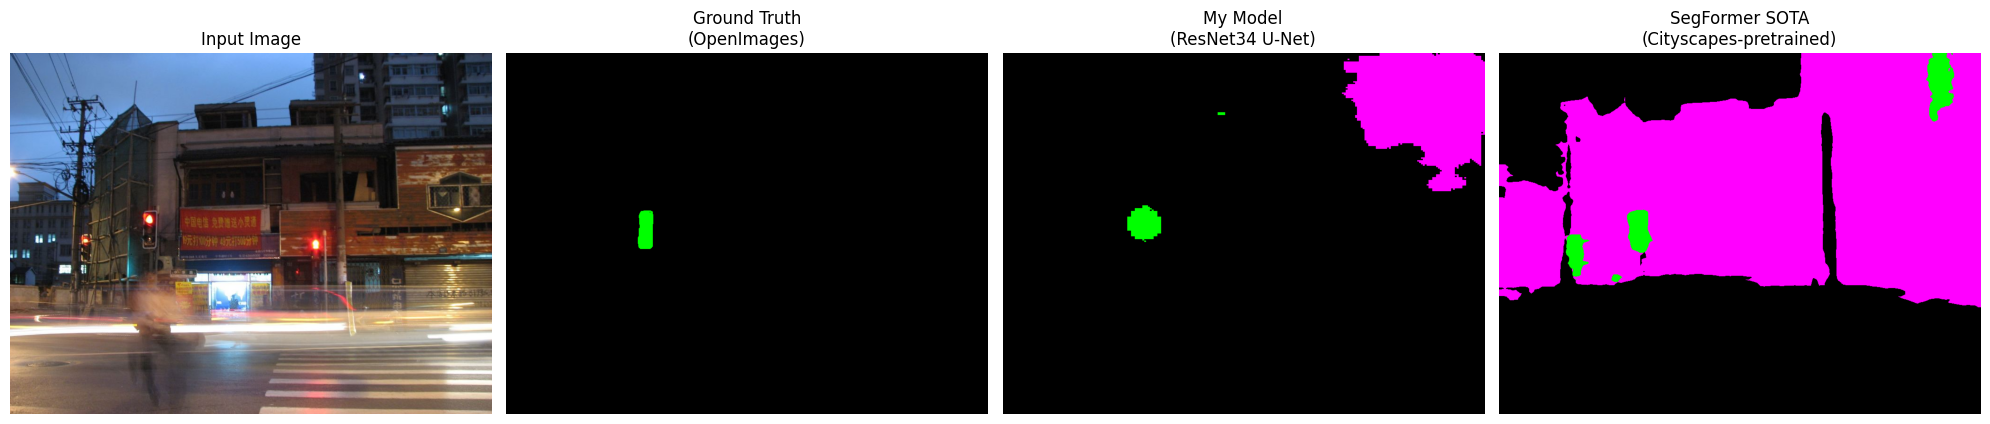

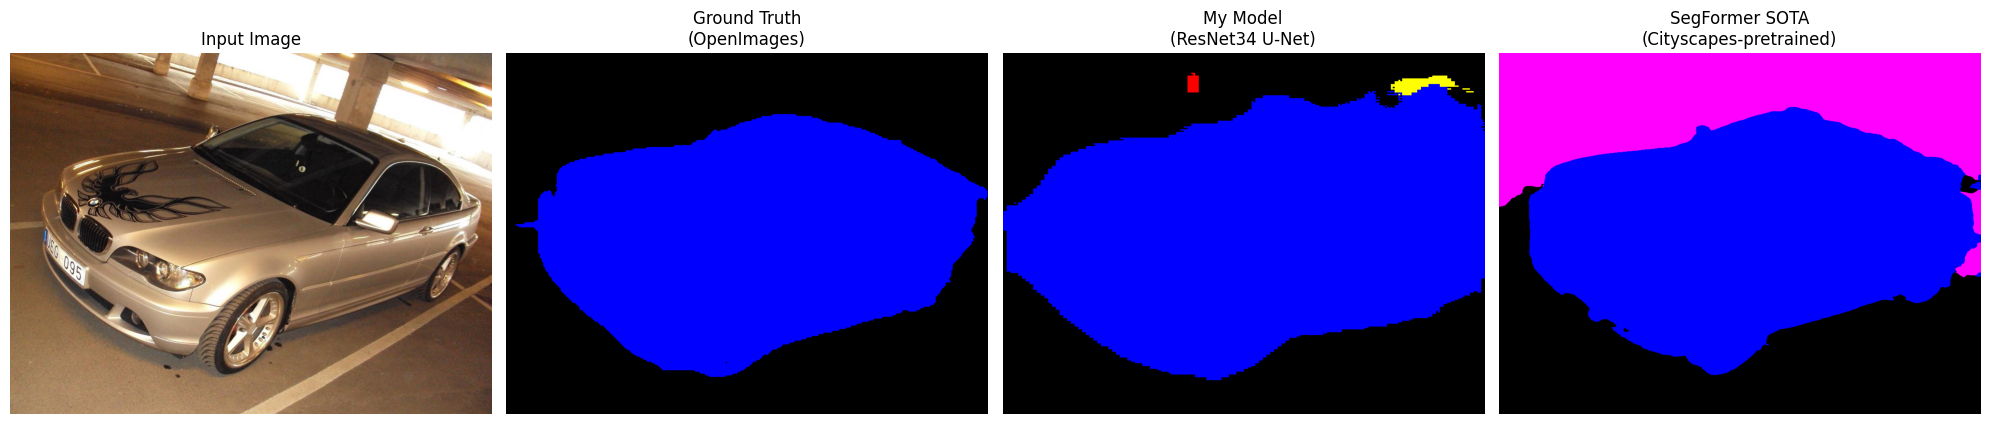

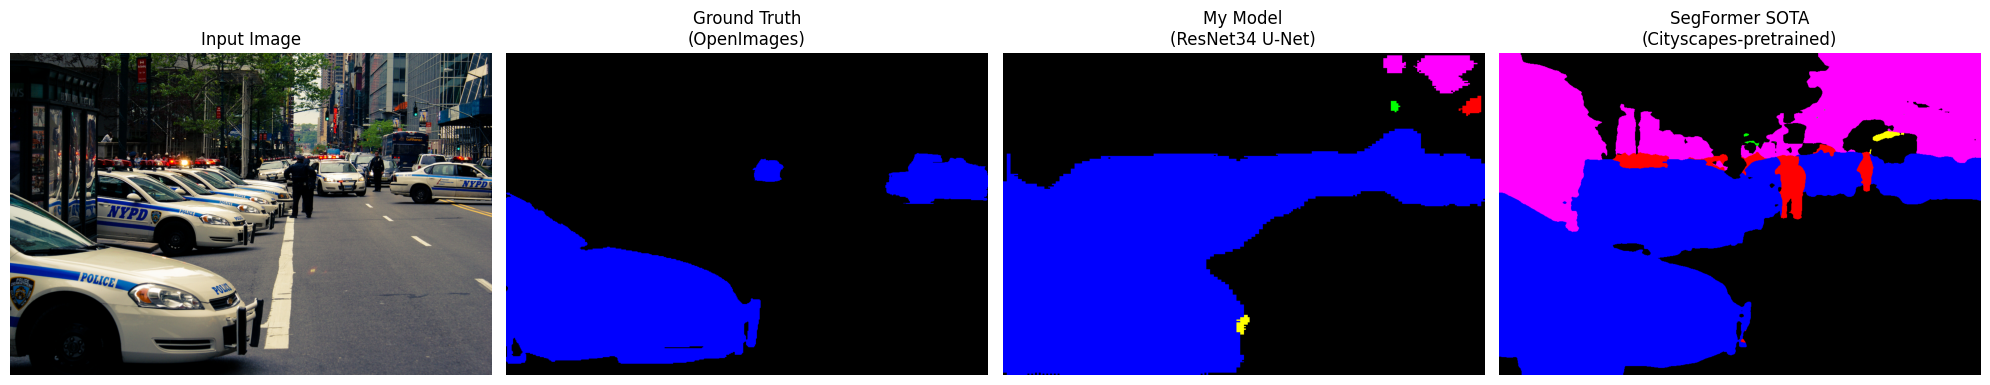

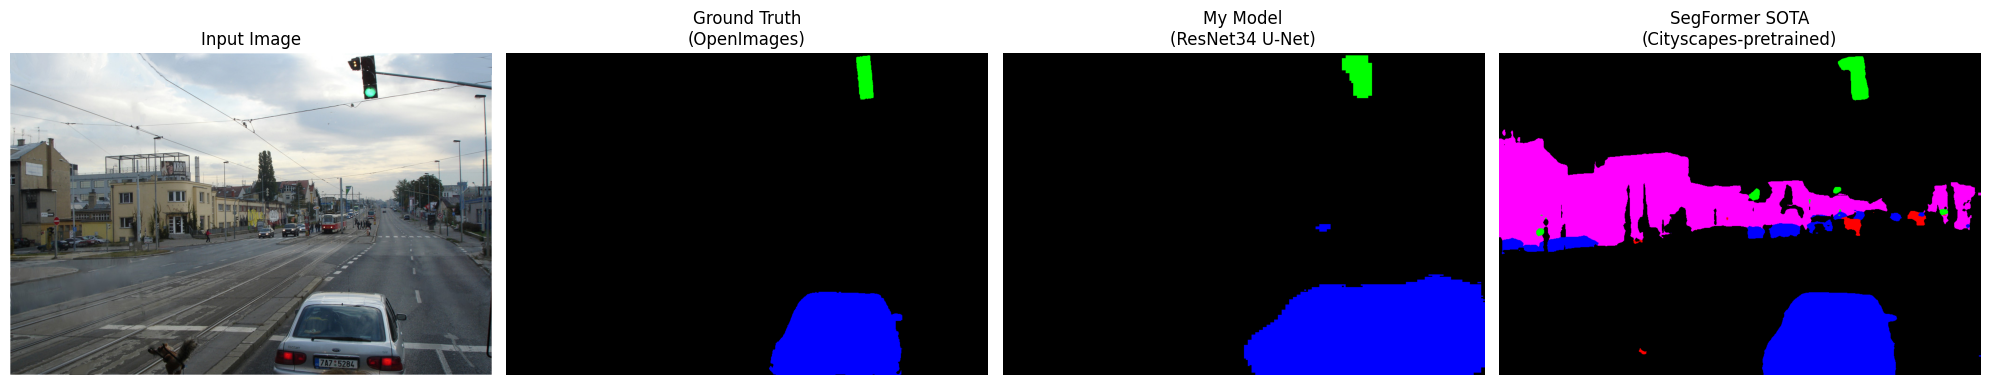

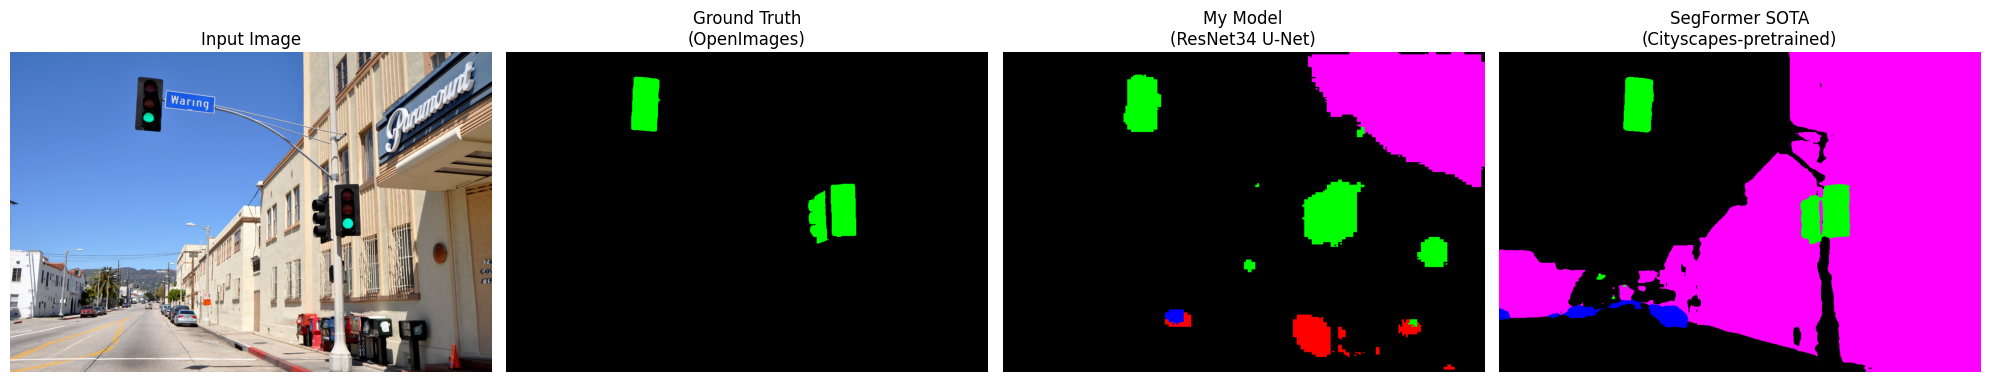

In [ ]:
# visual comparison on sample images
for img_id in test_ids[:5]:
    compare_models_visual(img_id)

In [16]:
@torch.no_grad()
# metrics for the created model vs SegFormer on test set
def eval_both_models(test_ids):

    stats = {'tp': np.zeros(6), 'fp': np.zeros(6), 'fn': np.zeros(6)}
    seg_stats = {'tp': np.zeros(6), 'fp': np.zeros(6), 'fn': np.zeros(6)}

    for img_id in test_ids:
        img_path = f'{IMG_DIR}/{img_id}.jpg'
        mask_path = f'{MASK_DIR}/{img_id}.png'

        # predictions
        pred, _ = predict(model, img_path, device)
        seg_pred, _ = predict_segformer(img_path)
        gt = np.array(Image.open(mask_path))

        # resize
        H, W = pred.shape
        gt = np.array(Image.fromarray(gt.astype(np.uint8)).resize((W, H), Image.NEAREST))
        seg_pred = np.array(Image.fromarray(seg_pred).resize((W, H), Image.NEAREST))

        # per-class stats
        for c in range(6):
            # unet
            stats['tp'][c] += ((pred == c) & (gt == c)).sum()
            stats['fp'][c] += ((pred == c) & (gt != c)).sum()
            stats['fn'][c] += ((pred != c) & (gt == c)).sum()

            # SegFormer
            seg_stats['tp'][c] += ((seg_pred == c) & (gt == c)).sum()
            seg_stats['fp'][c] += ((seg_pred == c) & (gt != c)).sum()
            seg_stats['fn'][c] += ((seg_pred != c) & (gt == c)).sum()

    return stats, seg_stats

stats, seg_stats = eval_both_models(test_ids)

In [17]:
# printed comparison table
def print_sota_comparison(stats, seg_stats):

    print(f"\n{'Class':<15} {'':^3} {'CREATED MODEL':^25} {'':^3} {'SEGFORMER ':^25}")
    print(f"{'':15} {'':^3} {'Prec':>8} {'Recall':>8} {'IoU':>8} {'':^3} {'Prec':>8} {'Recall':>8} {'IoU':>8}")
    print("-" * 95)

    metrics = {}
    seg_metrics = {}

    for c in range(1, 5):
        # my model
        tp, fp, fn = stats['tp'][c], stats['fp'][c], stats['fn'][c]
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)
        metrics[c] = {'p': p, 'r': r, 'iou': iou}

        # SegFormer
        tp, fp, fn = seg_stats['tp'][c], seg_stats['fp'][c], seg_stats['fn'][c]
        seg_p = tp / (tp + fp + 1e-8)
        seg_r = tp / (tp + fn + 1e-8)
        seg_iou = tp / (tp + fp + fn + 1e-8)
        seg_metrics[c] = {'p': seg_p, 'r': seg_r, 'iou': seg_iou}

        print(f"{CLASS_NAMES[c]:<15} {'':^3} {p:>8.3f} {r:>8.3f} {iou:>8.3f} {'':^3} {seg_p:>8.3f} {seg_r:>8.3f} {seg_iou:>8.3f}")

    print("-" * 95)

    # Macro averages
    macro_p = np.mean([metrics[c]['p'] for c in range(1, 5)])
    macro_r = np.mean([metrics[c]['r'] for c in range(1, 5)])
    macro_iou = np.mean([metrics[c]['iou'] for c in range(1, 5)])

    seg_macro_p = np.mean([seg_metrics[c]['p'] for c in range(1, 5)])
    seg_macro_r = np.mean([seg_metrics[c]['r'] for c in range(1, 5)])
    seg_macro_iou = np.mean([seg_metrics[c]['iou'] for c in range(1, 5)])

    print(f"{'MACRO AVG':<15} {'':^3} {macro_p:>8.3f} {macro_r:>8.3f} {macro_iou:>8.3f} {'':^3} {seg_macro_p:>8.3f} {seg_macro_r:>8.3f} {seg_macro_iou:>8.3f}")

    return metrics, seg_metrics

metrics, seg_metrics = print_sota_comparison(stats, seg_stats)


Class                     CREATED MODEL                  SEGFORMER         
                        Prec   Recall      IoU         Prec   Recall      IoU
-----------------------------------------------------------------------------------------------
Person                 0.257    0.863    0.247        0.277    0.918    0.270
Car                    0.526    0.912    0.501        0.685    0.944    0.659
Bus                    0.713    0.946    0.685        0.876    0.574    0.531
Traffic light          0.441    0.926    0.426        0.811    0.540    0.479
-----------------------------------------------------------------------------------------------
MACRO AVG              0.484    0.911    0.465        0.662    0.744    0.485


## Model Comparison for Saturation Analysis

The comparison with SegFormer was conducted to assess whether this custom model is approaching a performance saturation point on the dataset. In addition, it serves as a benchmark against SOTA model to evaluate whether further architectural improvements are likely to yield meaningful gains or whether performance is primarily constrained by dataset characteristics.

After aligning class definitions, the custom model was compared with SegFormer on four shared classes.

### Main observations

- The initial attempt to include the “skyscraper” class by mapping it to Cityscapes “building” revealed a semantic mismatch. Visual inspection and (initial run including this class) evaluation results showed that this mapping was unreliable, as SegFormer predictions were systematically penalized due to the broader definition of “building.” As a result -> this class was excluded from quantitative analysis.

- Similar overall IoU. Both models achieve comparable macro IoU (0.465 vs 0.485), with only a 0.02 difference despite fundamentally different architectures — a CNN-based U-Net versus a transformer-based model pretrained on a larger dataset.

- Opposing precision-recall trade-offs. The custom model demonstrates significantly higher recall (0.911 vs 0.744) but lower precision (0.484 vs 0.662). This indicates a tendency toward over-segmentation — the model finds most objects but also produces more false positives. SegFormer is more conservative, predicting fewer pixels overall but with higher confidence.

- Class-specific patterns. Both models struggle with the Person class (IoU ~0.25-0.27), suggesting this is a dataset-level challenge rather than a model-specific weakness. Interestingly, the custom model outperforms SegFormer on Bus (0.685 vs 0.531), while SegFormer shows better results for the rest of the classes.

### Interpretation

The results indicate a clear trade-off between recall and precision:
- The custom model prioritises coverage of objects (high recall) at the cost of increased false positives.
- SegFormer is more conservative, resulting in higher precision but lower recall.

Importantly, the relatively small IoU gap suggests that the custom model is already operating close to the performance level of a pretrained state-of-the-art model on this dataset. This supports the hypothesis that further architectural complexity may yield diminishing/marginal returns, and that performance is increasingly influenced by dataset characteristics / annotation issues rather than model capacity.

While SegFormer maintains an advantage in precision, the overall similarity in IoU suggests that the custom model may be approaching a saturation point in its current form, particularly for the evaluated class set.


## CLIP Comparison

Compare the created model with CLIP's zero-shot capabilities.

CLIP (Radford et al., 2021) computes similarity between an entire image and text descriptions. Given an image and the prompts ["person", "car", "bus", "traffic light", "skyscraper"], CLIP returns a probability distribution over these classes for the whole image.

Note that CLIP cannot tell *where* those objects are. It produces a single classification per image (just like ResNet34 did for the encoder portion of the model), not a segmentation mask. E.g. IoU or comparison of pixel-level predictions cannot be done.

Solution (?): CLIPSeg (Lüddecke & Ecker, 2022) that extends CLIP by adding a lightweight transformer decoder that produces dense predictions. Given the same text prompts, CLIPSeg outputs a probability map for each class at every pixel location.

**Purpose:** Answer the question *what accuracy can we achieve through text information alone?* This tests whether vision-language pretraining on 400 million image-text pairs can match task-specific training on 2,772 labeled masks.

**Expected:** Similar accuracy. CLIPSeg should recognize and localize our classes reasonably well, demonstrating that semantic understanding of urban scenes is "solved" across paradigms — the differences lie in boundary precision and rare object handling.

In [18]:
# load clipseg
clipseg_processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
clipseg_model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
clipseg_model.to(device)
clipseg_model.eval()

preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [19]:
@torch.no_grad()
# CLIPSeg zero-shot segmentation
def predict_clipseg(image_path):

    image = Image.open(image_path).convert('RGB')
    original_size = image.size  # (W, H)

    # same class prompts (skip background)
    prompts = ["person", "car", "bus", "traffic light", "skyscraper"]

    inputs = clipseg_processor(
        text=prompts,
        images=[image] * len(prompts),
        return_tensors="pt",
        padding=True
    ).to(device)

    outputs = clipseg_model(**inputs)

    # probability maps: [num_prompts, H, W]
    logits = outputs.logits
    probs = torch.sigmoid(logits).cpu().numpy()

    # resize to original size
    probs_resized = []
    for prob in probs:
        prob_img = Image.fromarray((prob * 255).astype(np.uint8))
        prob_resized = np.array(prob_img.resize(original_size, Image.BILINEAR)) / 255.0
        probs_resized.append(prob_resized)
    probs_resized = np.array(probs_resized)

    # combine into single mask
    # class = argmax of probs where max > threshold, else background
    combined = np.zeros((original_size[1], original_size[0]), dtype=np.uint8)
    max_probs = np.max(probs_resized, axis=0)
    argmax_probs = np.argmax(probs_resized, axis=0)

    threshold = 0.4
    combined[max_probs > threshold] = argmax_probs[max_probs > threshold] + 1

    return combined, probs_resized, np.array(image)

In [20]:
#  compare: GT → Unet model → CLIPSeg
def compare_with_clipseg(img_id):

    img_path = f'{IMG_DIR}/{img_id}.jpg'
    mask_path = f'{MASK_DIR}/{img_id}.png'

    # here - store predictions
    pred, img_np = predict(model, img_path, device)
    clipseg_pred, clipseg_probs, _ = predict_clipseg(img_path)
    gt = np.array(Image.open(mask_path))

    # resize to common size
    H, W = pred.shape
    gt = np.array(Image.fromarray(gt.astype(np.uint8)).resize((W, H), Image.NEAREST))
    clipseg_pred = np.array(Image.fromarray(clipseg_pred).resize((W, H), Image.NEAREST))

    # resize image
    img_resized = np.array(Image.fromarray(img_np).resize((W, H), Image.BILINEAR))

    # visuals
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    # row 1: segmentation comparison
    axes[0, 0].imshow(img_resized)
    axes[0, 0].set_title('Input Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(CLASS_COLOURS[gt])
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(CLASS_COLOURS[pred])
    axes[0, 2].set_title('Model')
    axes[0, 2].axis('off')

    axes[0, 3].imshow(CLASS_COLOURS[clipseg_pred])
    axes[0, 3].set_title('CLIPSeg (zero-shot)')
    axes[0, 3].axis('off')

    # Row 2: CLIPSeg per-class probabilities
    prompts = ["person", "car", "bus", "traffic light"]
    for i, (prompt, ax) in enumerate(zip(prompts, axes[1])):
        prob_resized = np.array(Image.fromarray((clipseg_probs[i] * 255).astype(np.uint8)).resize((W, H))) / 255.0
        ax.imshow(prob_resized, cmap='hot', vmin=0, vmax=1)
        ax.set_title(f'CLIPSeg: "{prompt}"')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/clipseg_comparison_{img_id}.png', dpi=150) # saving just in case
    plt.show()

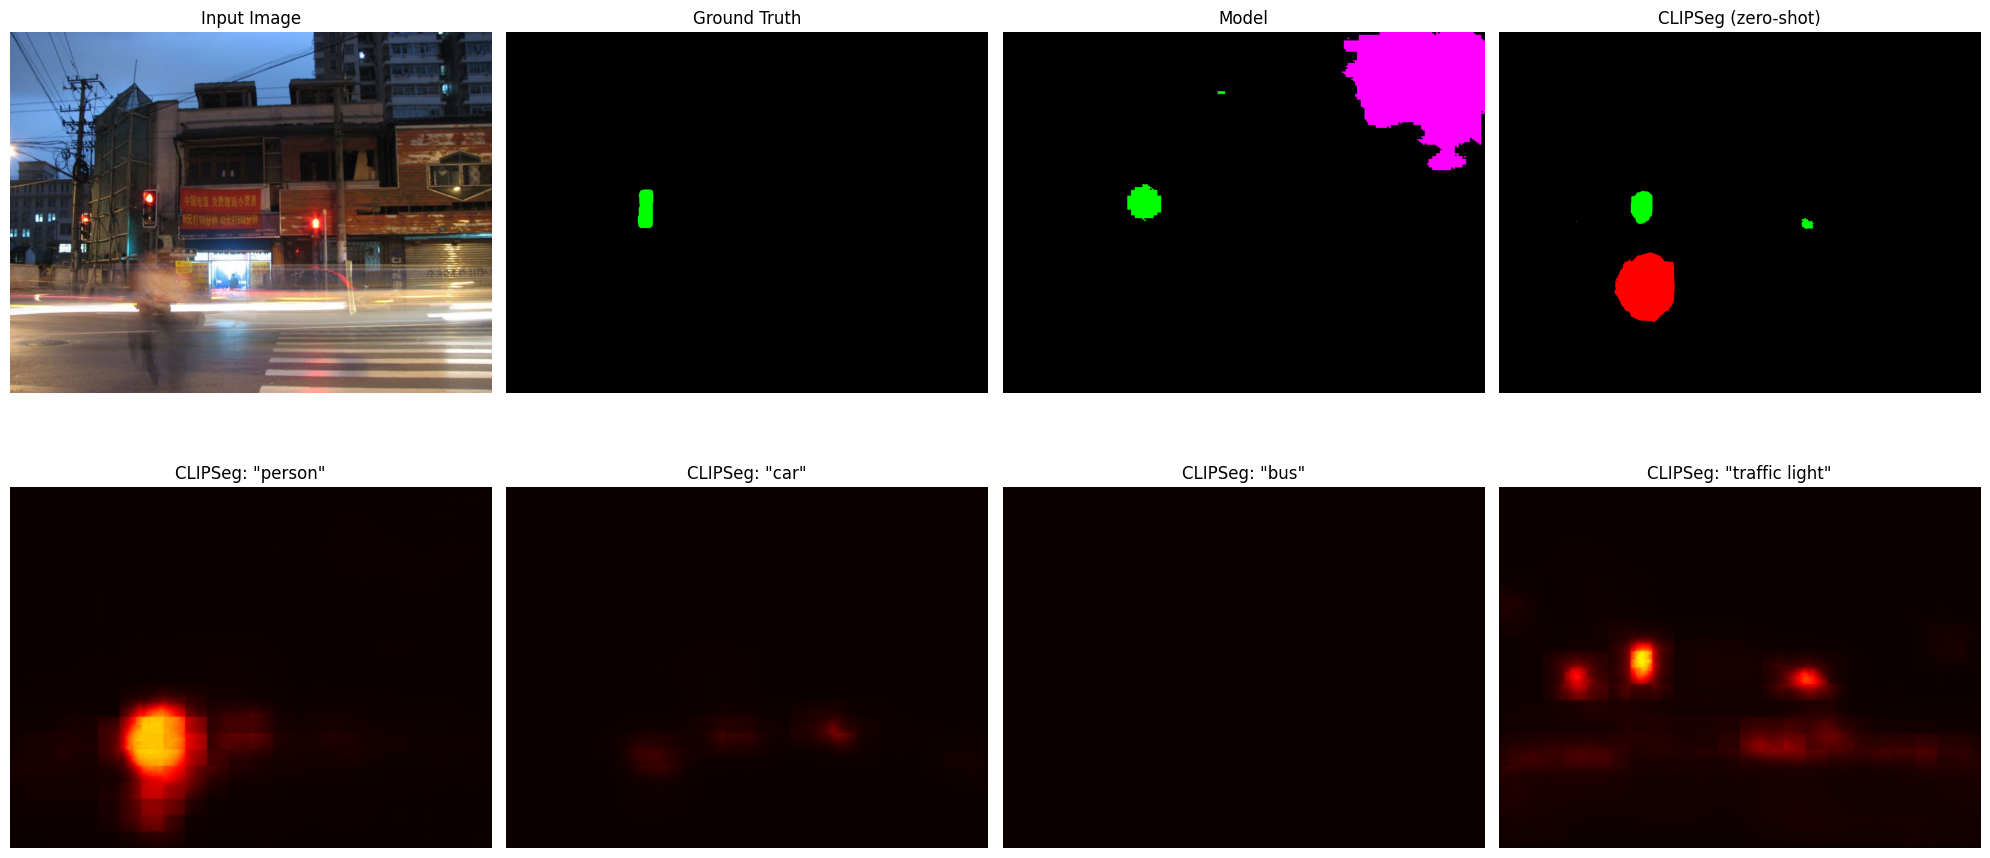

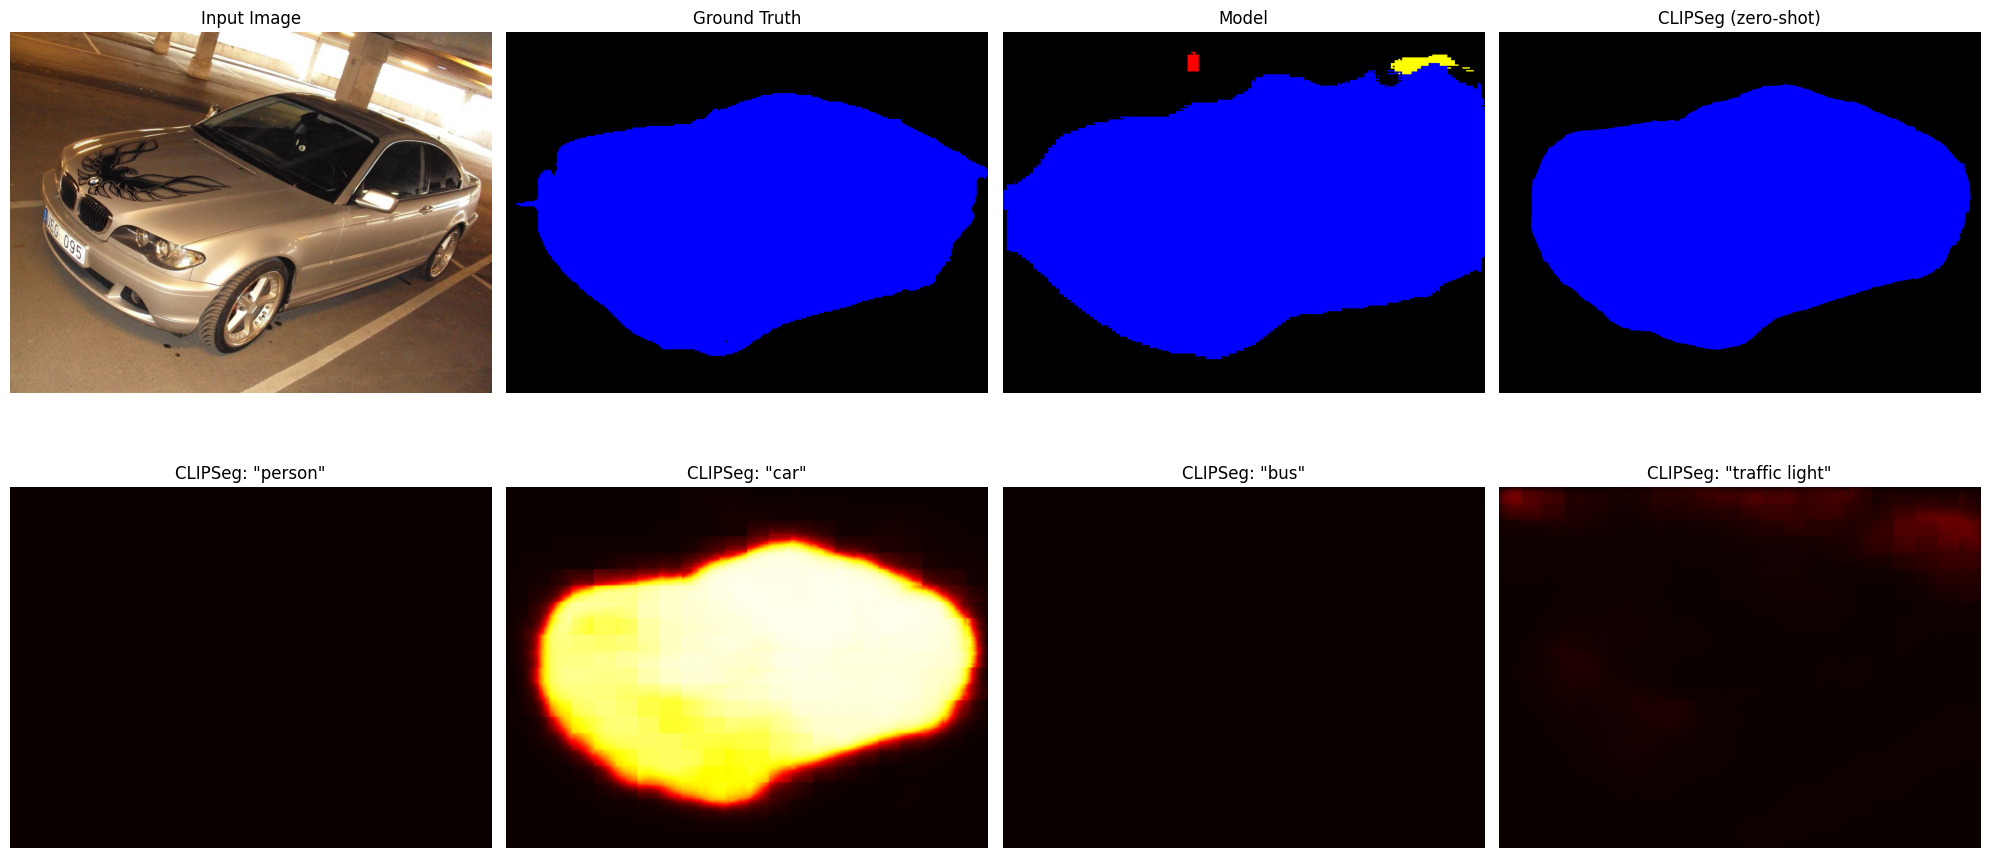

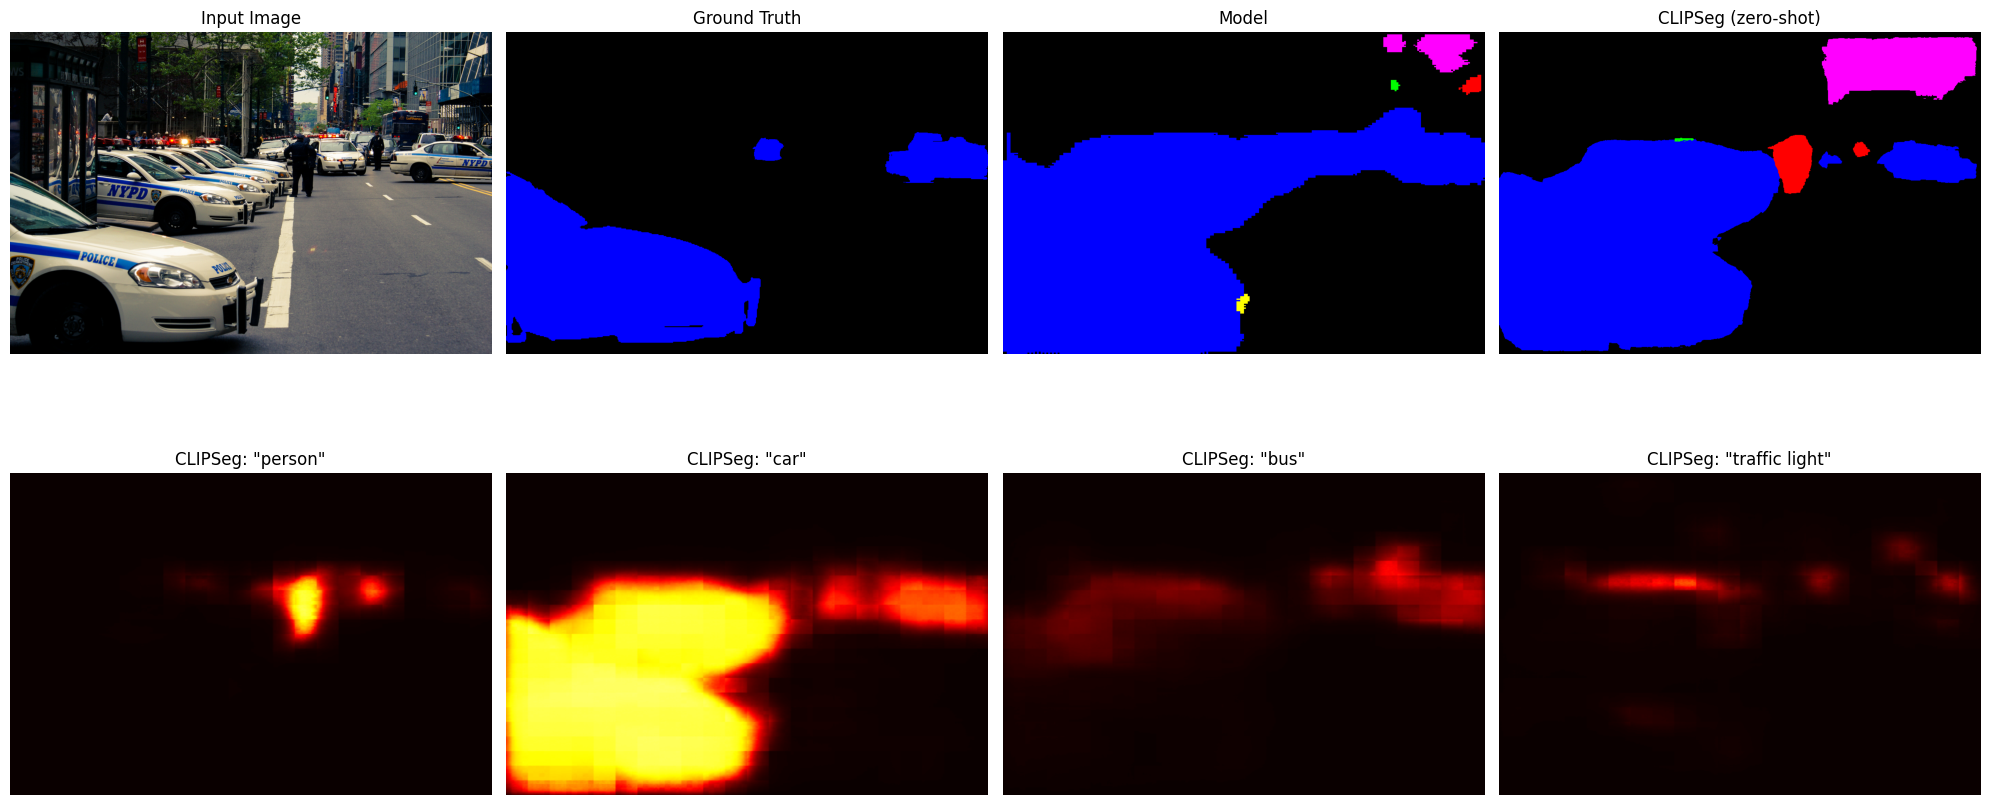

In [21]:
# compare on sample images
for img_id in test_ids[:3]:
    compare_with_clipseg(img_id)

In [22]:
@torch.no_grad()
# metrics for CLIPSeg
def evaluate_clipseg(test_ids):

    stats = {'tp': np.zeros(6), 'fp': np.zeros(6), 'fn': np.zeros(6)}

    for img_id in test_ids:
        img_path = f'{IMG_DIR}/{img_id}.jpg'
        mask_path = f'{MASK_DIR}/{img_id}.png'

        pred, _ = predict(model, img_path, device)
        clipseg_pred, _, _ = predict_clipseg(img_path)
        gt = np.array(Image.open(mask_path))

        H, W = pred.shape
        gt = np.array(Image.fromarray(gt.astype(np.uint8)).resize((W, H), Image.NEAREST))
        clipseg_pred = np.array(Image.fromarray(clipseg_pred).resize((W, H), Image.NEAREST))

        for c in range(6):
            stats['tp'][c] += ((clipseg_pred == c) & (gt == c)).sum()
            stats['fp'][c] += ((clipseg_pred == c) & (gt != c)).sum()
            stats['fn'][c] += ((clipseg_pred != c) & (gt == c)).sum()

    return stats

clipseg_stats = evaluate_clipseg(test_ids)

In [23]:
# printed metrics (for easier reading)
def print_clipseg_comparison(stats, clipseg_stats):

    print(f"\n{'Class':<15} {'':^3} {' UNET':^25} {'':^3} {'CLIPSEG (zero-shot)':^25}")
    print(f"{'':15} {'':^3} {'Prec':>8} {'Recall':>8} {'IoU':>8} {'':^3} {'Prec':>8} {'Recall':>8} {'IoU':>8}")
    print("-" * 95)

    for c in range(1, 6):
        # Unet
        tp, fp, fn = stats['tp'][c], stats['fp'][c], stats['fn'][c]
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        iou = tp / (tp + fp + fn + 1e-8)

        # CLIPSeg
        tp, fp, fn = clipseg_stats['tp'][c], clipseg_stats['fp'][c], clipseg_stats['fn'][c]
        clip_p = tp / (tp + fp + 1e-8)
        clip_r = tp / (tp + fn + 1e-8)
        clip_iou = tp / (tp + fp + fn + 1e-8)

        print(f"{CLASS_NAMES[c]:<15} {'':^3} {p:>8.3f} {r:>8.3f} {iou:>8.3f} {'':^3} {clip_p:>8.3f} {clip_r:>8.3f} {clip_iou:>8.3f}")

    print("-" * 95)

    # macro averages
    macro_iou = np.mean([stats['tp'][c] / (stats['tp'][c] + stats['fp'][c] + stats['fn'][c] + 1e-8) for c in range(1, 6)])
    clip_macro_iou = np.mean([clipseg_stats['tp'][c] / (clipseg_stats['tp'][c] + clipseg_stats['fp'][c] + clipseg_stats['fn'][c] + 1e-8) for c in range(1, 6)])

    print(f"\nMacro IoU: Unet = {macro_iou:.3f}, CLIPSeg = {clip_macro_iou:.3f}")

print_clipseg_comparison(stats, clipseg_stats)


Class                          UNET                  CLIPSEG (zero-shot)   
                        Prec   Recall      IoU         Prec   Recall      IoU
-----------------------------------------------------------------------------------------------
Person                 0.257    0.863    0.247        0.298    0.711    0.265
Car                    0.526    0.912    0.501        0.693    0.915    0.651
Bus                    0.713    0.946    0.685        0.858    0.884    0.772
Traffic light          0.441    0.926    0.426        0.789    0.747    0.623
Skyscraper             0.311    0.940    0.305        0.385    0.481    0.272
-----------------------------------------------------------------------------------------------

Macro IoU: Unet = 0.433, CLIPSeg = 0.517


### Main Observations

- CLIPSeg achieves higher overall IoU. Despite using zero training images from this dataset, CLIPSeg outperforms the supervised U-Net (0.517 vs 0.433 macro IoU).

- CLIPSeg wins on most classes. Car (0.651 vs 0.501), Bus (0.772 vs 0.685) and Traffic light (0.623 vs 0.426) all show substantial CLIPSeg advantages.

- Both models struggle with Person. IoU remains low for both (0.247 vs 0.265), confirming this as a dataset-level (quality, annotation, etc.) challenge.

- Skyscraper is the exception. The U-Net slightly outperforms CLIPSeg here (0.305 vs 0.272). This may reflect ambiguity in what "skyscraper" means, CLIPSeg's text prompt may not align well with the dataset's specific annotation criteria (might be similar ambiguity to SegFormer's building definition).

- The U-Net tends to over-segment (find everything, including false positives), while CLIPSeg is more selective.

### Interpretation

The CLIPSeg results confirm (?) the (near-to) saturation hypothesis from a different angle. A model using only class names as supervision achieves competitive (more like superior), results to one trained on 2,772 pixel-annotated images, suggesting that the semantic understanding required is already well captured by general vision-language pretraining. At the same time, similar failure modes persist, as both approaches struggle with the “Person” class and exhibit a precision–recall trade-off pattern, indicating that the bottleneck lies in the inherent difficulty of the task and annotation quality.

There is a pretty clear convergence across all three: a supervised CNN (U-Net), a supervised transformer (SegFormer) and a zero-shot text-prompted model (CLIPSeg) all achieve IoU scores in the 0.43 to 0.52 range, pointing to dataset-level saturation rather than model-level limitations.

## Feature clustering

Q: Does custom Unet and CLIP learn similar representations?

Extract features from both models and compare:
1. **t-SNE visualization**. Do features cluster by class?
2. **Clustering metrics**. ARI (Adjusted Rand Index), NMI (Normalized Mutual Info)

If both models show similar clustering quality, it suggests Unet model learned
representations comparable to CLIP despite far less training data.

In [27]:
# for this part - need CLIP itself
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model = clip_model.float()
clip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [31]:
@torch.no_grad()
# spatial features from ResNet encoder
def extract_resnet_features(model, test_ids, num_images=25):

    model.eval()

    all_features = []
    all_labels = []

    features_captured = []
    def hook_fn(module, input, output):
        features_captured.append(output.detach())

    handle = model.encoder4.register_forward_hook(hook_fn)

    for img_id in test_ids[:num_images]:
        features_captured.clear()

        # preprocessing part
        img = Image.open(f'{IMG_DIR}/{img_id}.jpg').convert('RGB').resize((256, 256))
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_tensor = ((img_tensor - mean) / std).unsqueeze(0).to(device)

        _ = model(img_tensor)

        # [512, 8, 8] → [8, 8, 512]
        feat = features_captured[0].squeeze().cpu().numpy()
        feat = feat.transpose(1, 2, 0)

        # downsample mask to 8x8
        mask = np.array(Image.open(f'{MASK_DIR}/{img_id}.png').resize((8, 8), Image.NEAREST))

        for i in range(8):
            for j in range(8):
                all_features.append(feat[i, j])
                all_labels.append(mask[i, j])

    handle.remove()
    return np.array(all_features), np.array(all_labels)


@torch.no_grad()
# spatial features from CLIP ViT
def extract_clip_features(test_ids, num_images=25):

    all_features = []
    all_labels = []

    for img_id in test_ids[:num_images]:
        img_path = f'{IMG_DIR}/{img_id}.jpg'

        image = Image.open(img_path).convert('RGB')
        image_input = clip_preprocess(image).unsqueeze(0).to(device)

        vit = clip_model.visual

        # patch embedding: [1, 768, 7, 7]
        x = vit.conv1(image_input)
        x = x.reshape(x.shape[0], x.shape[1], -1)  # [1, 768, 49]
        x = x.permute(0, 2, 1)  # [1, 49, 768]

        # class token
        cls_token = vit.class_embedding.unsqueeze(0).unsqueeze(0)  # [1, 1, 768]
        x = torch.cat([cls_token, x], dim=1)  # [1, 50, 768]

        # positional embedding
        x = x + vit.positional_embedding.unsqueeze(0)
        x = vit.ln_pre(x)

        # transformer
        x = x.permute(1, 0, 2)  # [50, 1, 768]
        x = vit.transformer(x)
        x = x.permute(1, 0, 2)  # [1, 50, 768]

        # patch features (skip CLS token): [49, 768] → [7, 7, 768]
        patch_features = x[0, 1:, :].cpu().numpy().reshape(7, 7, -1)

        # downsample mask to 7x7
        mask = np.array(Image.open(f'{MASK_DIR}/{img_id}.png').resize((7, 7), Image.NEAREST))

        for i in range(7):
            for j in range(7):
                all_features.append(patch_features[i, j])
                all_labels.append(mask[i, j])

    return np.array(all_features), np.array(all_labels)

In [32]:
NUM_IMAGES = 50

resnet_features, resnet_labels = extract_resnet_features(model, test_ids, NUM_IMAGES)
clip_features, clip_labels = extract_clip_features(test_ids, NUM_IMAGES)

In [34]:
# t-SNE
tsne_resnet = TSNE(n_components=2, random_state=123, perplexity=30)
resnet_2d = tsne_resnet.fit_transform(resnet_features)

tsne_clip = TSNE(n_components=2, random_state=123, perplexity=30)
clip_2d = tsne_clip.fit_transform(clip_features)

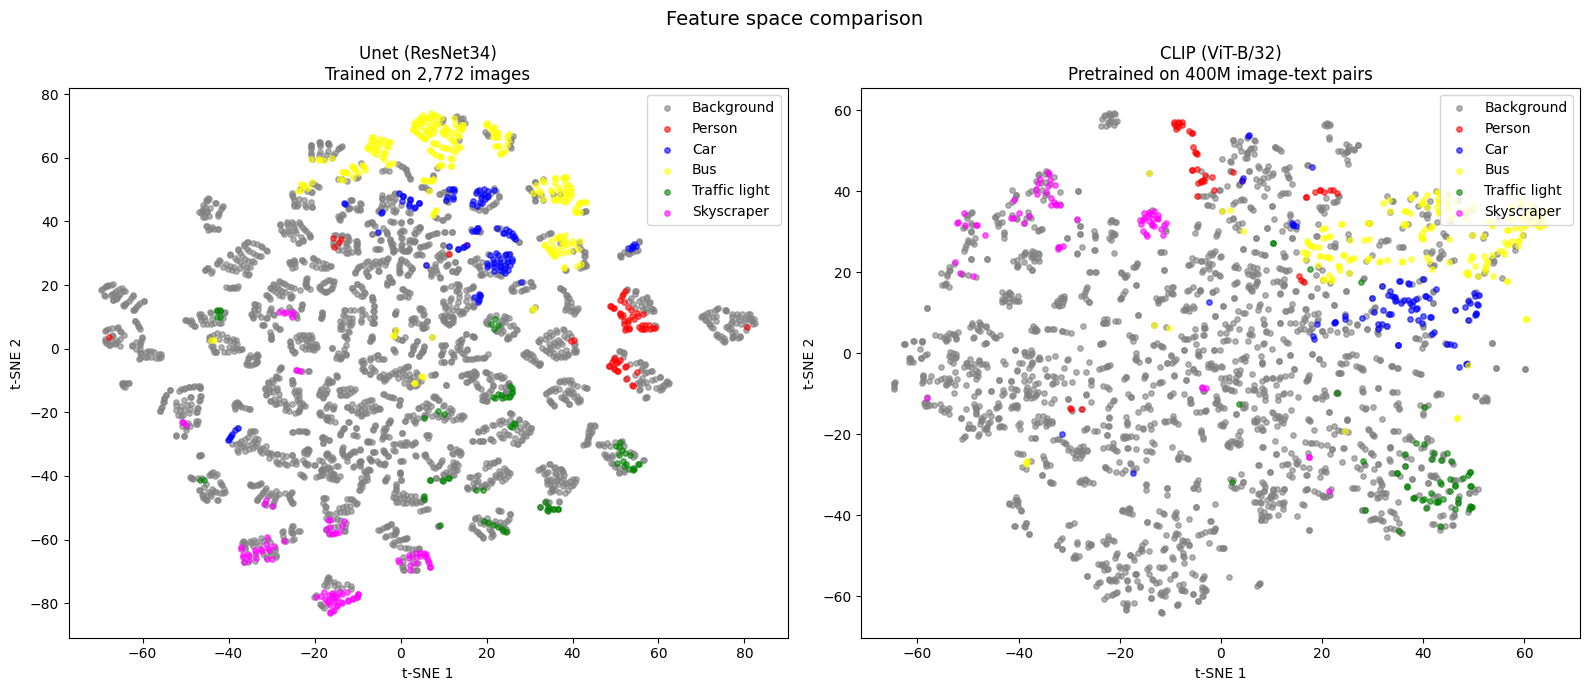

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['gray', 'red', 'blue', 'yellow', 'green', 'magenta']

for ax, features_2d, labels, title in [
    (axes[0], resnet_2d, resnet_labels, "Unet (ResNet34)\nTrained on 2,772 images"),
    (axes[1], clip_2d, clip_labels, "CLIP (ViT-B/32)\nPretrained on 400M image-text pairs")
]:
    for c in range(6):
        mask = labels == c
        if mask.sum() > 0:
            ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                       c=colors[c], label=f'{CLASS_NAMES[c]}', alpha=0.6, s=15)
    ax.legend(loc='upper right')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('Feature space comparison', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_clustering_comparison.png', dpi=150) # maybe will need the image
plt.show()

Looking at the image:
despite CLIP achieving similar segmentation accuracy, the feature representations differ. Custom U-Net model produces tightly clustered, class-discriminative features. CLIP's features are more diffuse, it achieves good segmentation through its decoder (CLIPSeg) rather than through class-specific encoding.

In [36]:
# clustering metrics
def evaluate_clustering(features, labels, name):

    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features)

    ari = adjusted_rand_score(labels, cluster_labels)
    nmi = normalized_mutual_info_score(labels, cluster_labels)

    return {'ari': ari, 'nmi': nmi}

resnet_clustering = evaluate_clustering(resnet_features, resnet_labels, "ResNet")
clip_clustering = evaluate_clustering(clip_features, clip_labels, "CLIP")

print(f"\n{'Metric':<25} {'Unet':>15} {'CLIP':>15}")
print("-" * 60)
print(f"{'ARI':<25} {resnet_clustering['ari']:>15.4f} {clip_clustering['ari']:>15.4f}")
print(f"{'NMI':<25} {resnet_clustering['nmi']:>15.4f} {clip_clustering['nmi']:>15.4f}")


Metric                               Unet            CLIP
------------------------------------------------------------
ARI                                0.1305          0.0472
NMI                                0.2306          0.1567
